# Set up

In [4]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [6]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set_theme()

In [7]:
import pickle
with open('membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [6]:
membership[0]

,probe,group_id
unit_ids,,
951800803,probeC,0
951800819,probeC,1
951800831,probeC,2
951800909,probeC,1
951800900,probeC,2
...,...,...
951819836,probeE,0
951819902,probeE,1
951820372,probeE,2


In [7]:
condition_ids

[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270]

In [8]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Test penalized GLM

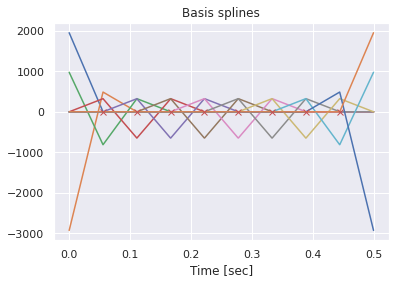

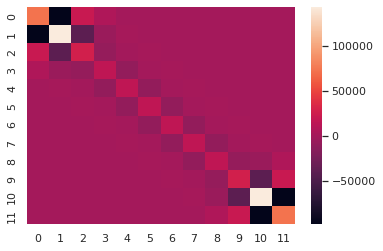

In [14]:
time_line = np.arange(0,0.5,1/1e3)
fit_model = smoothing_spline.SmoothingSpline()
f_basis, f_Omega = fit_model.construct_basis_omega(
    time_line, knots=10, verbose=True)

In [ ]:
f_basis

In [115]:
from scipy.special import rel_entr
from scipy.stats import kstest
from scipy.stats import wasserstein_distance
from scipy.stats import norm
from scipy.stats import uniform

def get_three_measure(pdf, xx, dx):
    cdf = np.zeros_like(pdf)
    cdf = np.cumsum(pdf*dx)
    pdfUniform = 1*np.ones(len(xx))
    cdfUniform = np.zeros_like(pdfUniform)
    cdfUniform = np.cumsum(pdfUniform*dx)
    KL = rel_entr(pdfUniform, pdf).sum()
    KS = np.max(np.abs(cdf-cdfUniform))
    Wasser = np.sum(np.abs(cdf-cdfUniform))
#     print([KL, KS, Wasser])
    return [KL, KS, Wasser]


[154.49108296077833, 0.125941149958947, 70.03570059801811]


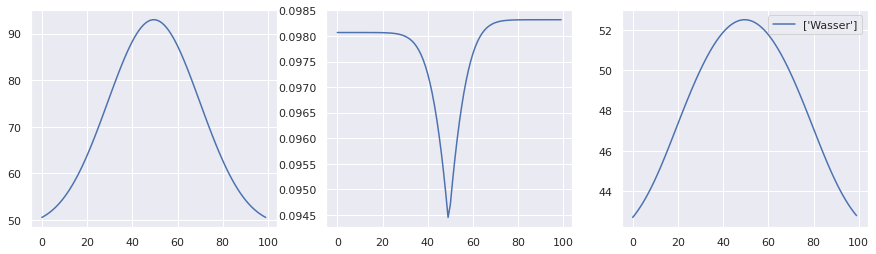

In [124]:
amp = 0.5
baseline = 1
wid = 0.05
center1 = 0.5
center2 = 0.8
dx = 0.001
xx = np.arange(0, 1, dx)
results = []
neuron1 = amp*norm(center1, wid).pdf(xx) + baseline
for center2 in np.linspace(0.3,0.7,100):
    neuron2 = amp*norm(center2, wid).pdf(xx) + 2*baseline
    pdfP = neuron1 + neuron2
    pdfP = pdfP/np.mean(pdfP)
    results.append(get_three_measure(pdfP, xx, dx))
results = np.array(results)
plt.subplots(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(results[:,0], label=['KL', 'KS', 'Wasser'])
plt.subplot(1,3,2)
plt.plot(results[:,1], label=['KS'])
plt.subplot(1,3,3)
plt.plot(results[:,2], label=['Wasser'])
plt.legend()

pdfP = neuron1
pdfP = pdfP/np.mean(pdfP)
print(get_three_measure(pdfP, xx, dx))

In [68]:
V1.spike_train

,3798,3800,3809,3810,3824,3827,3830,3831,3832,3834,...,49392,49396,49400,49406,49408,49415,49422,49423,49424,49428
units,,,,,,,,,,,,,,,,,,,,,
951800803,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
951800819,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
951800831,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
951800909,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0

In [65]:
results_list = []

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC'))

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC',penalization=1e-1,L2_wt=0.99999))

label_list = ['running', 'running with penalty']

Negative log likelihood is: 28017.97
aic/2 is: 28048.97
Negative log likelihood is: 29364.09
aic/2 is: 29395.09


/home/qix/anaconda3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1346: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")
